# Aula Completa: Clusterização Hierárquica com Iris

Notebook completo com teoria, dendrogramas, comparação com K-Means e DBSCAN, avaliação por Silhouette e análise dos métodos de ligação.

## Objetivos
- Entender o algoritmo hierárquico aglomerativo
- Interpretar dendrogramas
- Escolher K usando dendrograma e Silhouette
- Comparar Single, Complete, Average e Ward
- Comparar Hierárquico, K-Means e DBSCAN
- Visualizar clusters com PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram


## Carregando o Dataset Iris
O Iris possui 150 observações e 4 atributos relacionados a flores de três espécies.

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
X.shape

(150, 4)

## Normalização
Métodos baseados em distância são sensíveis à escala das variáveis.

In [4]:
X_scaled = StandardScaler().fit_transform(X)

## Intuição do Algoritmo Hierárquico

1. Cada observação inicia como um cluster.
2. Calculam-se as distâncias entre clusters.
3. Os dois clusters mais próximos são unidos.
4. O processo continua até existir apenas um cluster.
5. O histórico completo das fusões forma o dendrograma.


## Construção do Dendrograma (Ward)
O dendrograma mostra todas as fusões realizadas pelo algoritmo.

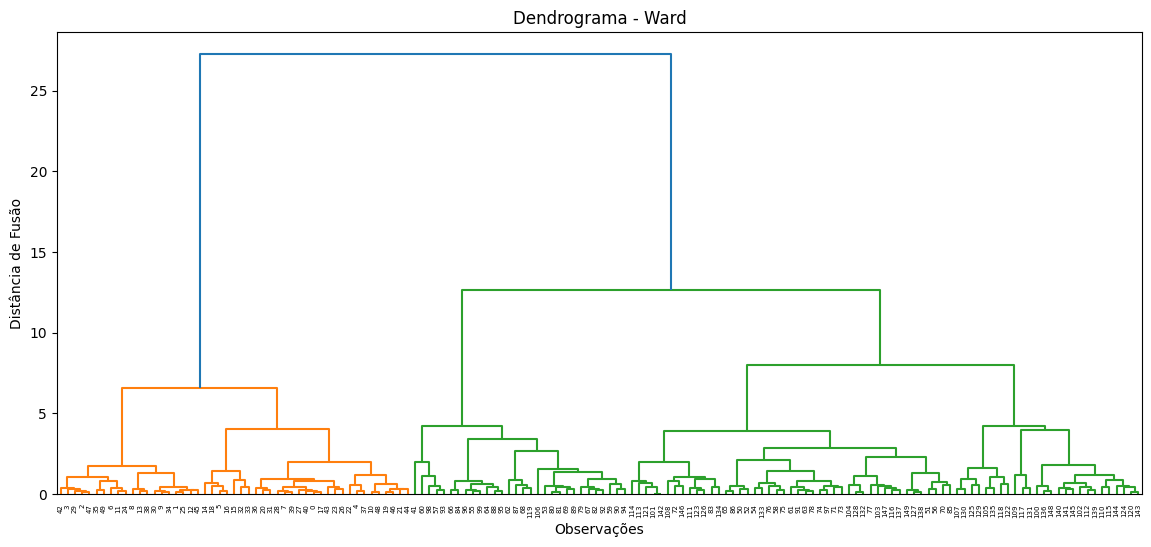

In [5]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14,6))
dendrogram(Z)
plt.title('Dendrograma - Ward')
plt.xlabel('Observações')
plt.ylabel('Distância de Fusão')
plt.show()

## Como Escolher o Número de Clusters?

Observe os maiores saltos verticais do dendrograma.
Grandes saltos indicam que clusters bastante diferentes foram unidos.
Um corte horizontal antes desses saltos normalmente produz uma boa solução.


## Comparando Métodos de Ligação
Cada método define a distância entre clusters de maneira diferente.

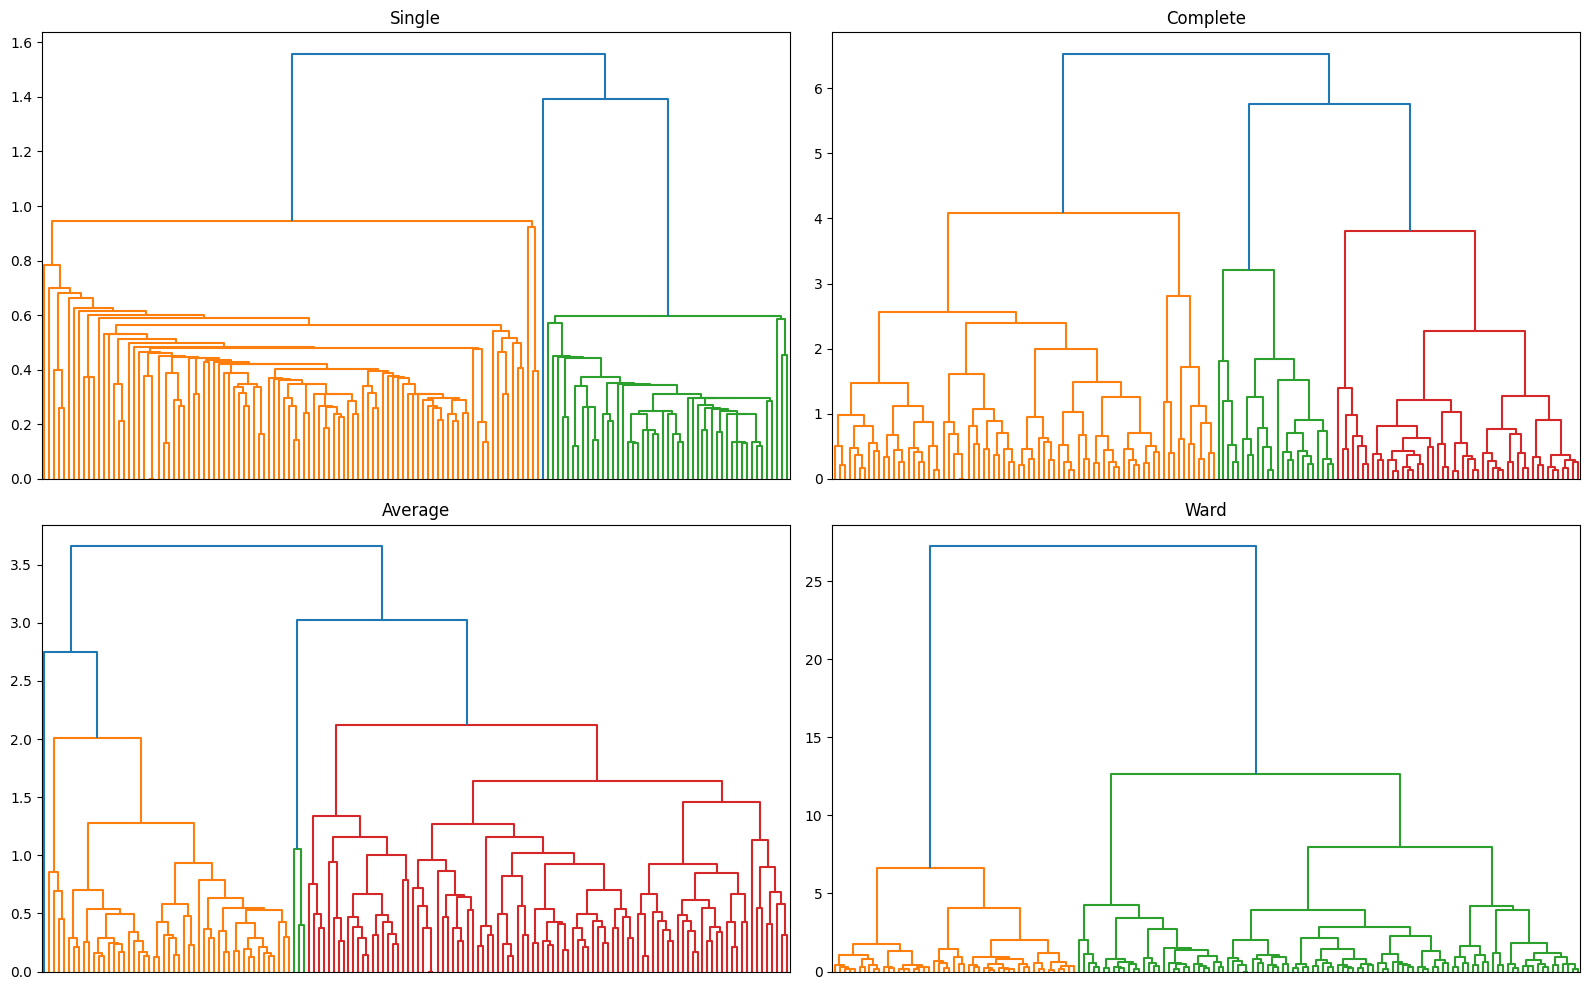

In [6]:
methods = ['single','complete','average','ward']

plt.figure(figsize=(16,10))

for i, method in enumerate(methods,1):
    plt.subplot(2,2,i)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, no_labels=True)
    plt.title(method.title())

plt.tight_layout()
plt.show()

### Single Linkage
Menor distância entre elementos dos clusters.

### Complete Linkage
Maior distância entre elementos dos clusters.

### Average Linkage
Distância média entre elementos dos clusters.

### Ward Linkage
Minimiza a variabilidade interna dos grupos.


## Aplicando Clusterização Hierárquica

In [7]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

## PCA para Visualização

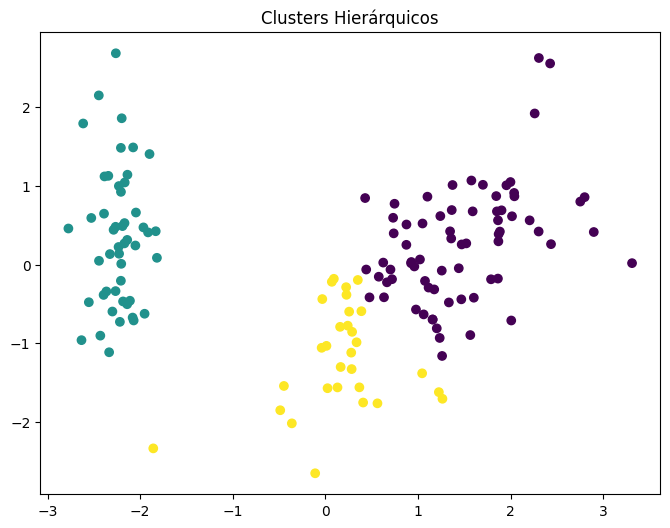

In [8]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hc, cmap='viridis')
plt.title('Clusters Hierárquicos')
plt.show()

## Avaliação com Silhouette Score

In [9]:
sil_hc = silhouette_score(X_scaled, labels_hc)
print('Hierárquico:', round(sil_hc,4))

Hierárquico: 0.4467


## Escolha de K utilizando Silhouette

In [10]:
scores=[]

for k in range(2,11):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f'k={k}: {score:.4f}')

k=2: 0.5770
k=3: 0.4467
k=4: 0.4006
k=5: 0.3306
k=6: 0.3149
k=7: 0.3170
k=8: 0.3109
k=9: 0.3114
k=10: 0.3161


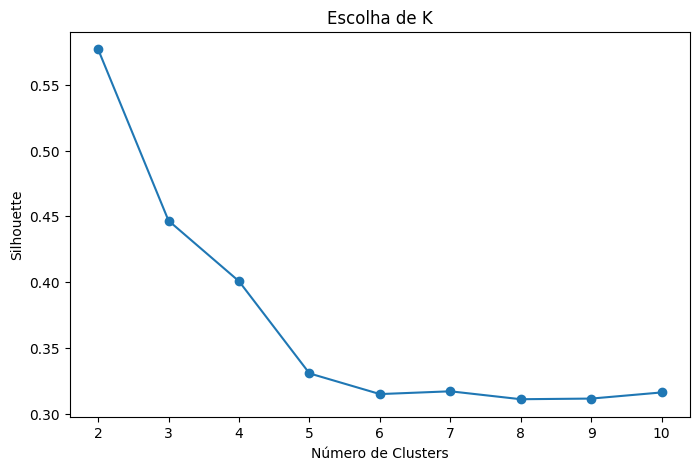

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette')
plt.title('Escolha de K')
plt.show()

## Comparação dos Métodos de Ligação via Silhouette

In [12]:
for method in ['single','complete','average','ward']:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'{method:10s} -> {score:.4f}')

single     -> 0.5046
complete   -> 0.4496
average    -> 0.4803
ward       -> 0.4467


## Comparação com K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
print('K-Means:', round(sil_kmeans,4))

K-Means: 0.4599


## Comparação com DBSCAN

In [14]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

valid = len(set(labels_dbscan)) > 1 and len(set(labels_dbscan)) < len(labels_dbscan)

if valid:
    sil_dbscan = silhouette_score(X_scaled, labels_dbscan)
    print('DBSCAN:', round(sil_dbscan,4))
else:
    sil_dbscan = np.nan
    print('DBSCAN não produziu clusters adequados para Silhouette')

DBSCAN: 0.5217


## Comparação Final dos Algoritmos

In [15]:
results = pd.DataFrame({
    'Método':['Hierárquico','K-Means','DBSCAN'],
    'Silhouette':[sil_hc, sil_kmeans, sil_dbscan]
})

results

,Método,Silhouette
0,Hierárquico,0.446689
1,K-Means,0.459948
2,DBSCAN,0.521697


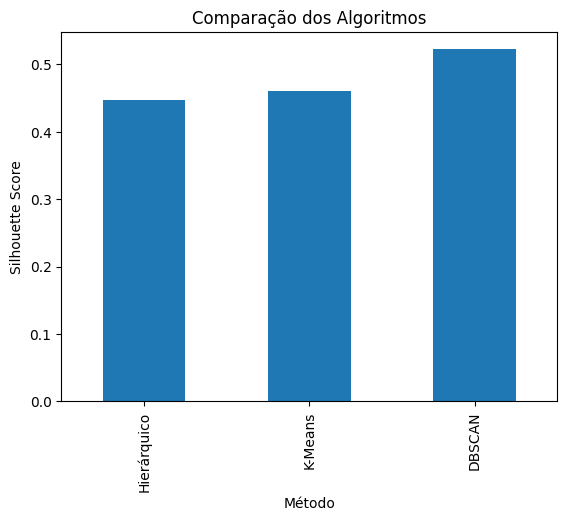

In [16]:
results.plot.bar(x='Método', y='Silhouette', legend=False)
plt.ylabel('Silhouette Score')
plt.title('Comparação dos Algoritmos')
plt.show()

## Conclusões

- O dendrograma fornece uma visão completa da estrutura dos dados.
- O Silhouette ajuda a validar quantitativamente os agrupamentos.
- Ward costuma apresentar excelente desempenho em dados compactos.
- K-Means é mais escalável para grandes bases.
- DBSCAN é superior quando existem outliers e formatos complexos.
- Métodos hierárquicos são excelentes para análise exploratória e interpretação.
